# 04 · Zone opportunity scores (0–100)

Turns the feature table and the regression into a **ranked shortlist of municipalities** for a charge-point
operator: where is there EV demand, little public supply to serve it, and somewhere to build?

**Why a composite and not just the model gap.** Notebook 03 showed that fundamentals explain little of where
chargers are, and no single municipality's shortfall is statistically certain. So the model gap is one
signal among five, weighted transparently, and the ranking is stress-tested under different weightings.

| Component | Measures | Column(s) |
|---|---|---|
| **Market size** | resident EVs (fleet-corrected) | `ev_resident_est` |
| **Home-charging gap** | apartment living / no private garage | `pop_density_km2` |
| **Supply scarcity** | resident EVs per public charging point | `ev_resident_est`, `public_points` |
| **Model shortfall** | fewer points than peers with the same fundamentals | `expected` (from 03) |
| **Site availability** | fuel stations as conversion sites (strongest predictor in 03) | `fuel_stations` |

Each component becomes a percentile among eligible municipalities. The score is their **weighted geometric mean**,
rescaled to 0–100. A geometric mean requires a municipality to do reasonably on every component: being big cannot
make up for already being well served. (A plain weighted average was tried first and mostly reproduced population
density, ρ = 0.76; section 2 re-runs that check.)

**Inputs:** `features_municipal.gpkg`, `model_predictions.csv` · **Outputs:** `data/processed/zone_scores.csv`,
`report/top20_candidates.md`, `maps/04_*.png`, and Power BI tables in `dashboard/data/`

## 0 · Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Patch

if Path.cwd().name == "notebooks":
    os.chdir("..")
PROC = Path("data/processed")
for d in ("maps", "report"):
    Path(d).mkdir(exist_ok=True)

feat = gpd.read_file(PROC / "features_municipal.gpkg")
feat["ine_code"] = feat["ine_code"].astype(str)
pred = pd.read_csv(PROC / "model_predictions.csv", dtype={"ine_code": str})[["ine_code", "expected", "p_shortfall"]]
z = feat.merge(pred, on="ine_code", how="left")
print(f"{len(z)} municipalities; model predictions for {z['expected'].notna().sum()}")

# Chart style
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
NOT_RANKED = "#e9e8e4"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list(          # red = fewer points than expected, blue = more
    "gap", ["#b8302f", "#e34948", "#f2a3a2", "#f0efec", "#9ec5f4", "#3987e5", "#184f95"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
})

179 municipalities; model predictions for 179


## 1 · Eligibility and components

Municipalities below `MIN_POP` residents are scored but **not ranked**: a commercial station needs a minimum
catchment, and per-resident ratios are unstable for tiny populations (a single charger swings them wildly).

In [2]:
MIN_POP = 5_000

z["eligible"] = z["population"] >= MIN_POP
z["evs_per_public_point"] = z["ev_resident_est"] / (z["public_points"] + 1)
z["model_ratio"] = (z["public_points"] + 1) / (z["expected"] + 1)          # < 1: fewer than peers
z["model_shortfall"] = -np.log(z["model_ratio"])                            # > 0: shortfall

COMPONENTS = {                       # component -> (column, higher value = more opportunity?)
    "market":   ("ev_resident_est",      True),
    "home_gap": ("pop_density_km2",      True),
    "scarcity": ("evs_per_public_point", True),
    "model":    ("model_shortfall",      True),
    "sites":    ("fuel_stations",        True),
}

elig = z["eligible"]
for comp, (col, higher) in COMPONENTS.items():
    r = z.loc[elig, col].rank(pct=True, ascending=higher)
    z.loc[elig, f"pct_{comp}"] = r
print(f"{elig.sum()} of {len(z)} municipalities eligible (≥ {MIN_POP:,} residents), "
      f"holding {z.loc[elig, 'population'].sum() / z['population'].sum():.0%} of the population")

83 of 179 municipalities eligible (≥ 5,000 residents), holding 98% of the population


## 2 · Score

Base weights put the most weight on **scarcity** and the **model gap** (undersupply), balanced against market size
and density (demand). Change them here; everything below updates.

In [3]:
from scipy.stats import spearmanr

WEIGHTS = {"market": 0.25, "home_gap": 0.15, "scarcity": 0.30, "model": 0.20, "sites": 0.10}

def score(df, weights):
    """Weighted geometric mean of percentiles: a municipality needs demand AND undersupply,
    so a strong showing on size cannot make up for already being well served."""
    w = pd.Series(weights, dtype=float)
    w = w[w > 0] / w[w > 0].sum()
    raw = np.exp(sum(np.log(df[f"pct_{c}"]) * wt for c, wt in w.items()))
    lo, hi = raw[df["eligible"]].min(), raw[df["eligible"]].max()
    return ((raw - lo) / (hi - lo) * 100).where(df["eligible"])

z["score"] = score(z, WEIGHTS)
z["rank"] = z["score"].rank(ascending=False, method="min")
print(z.loc[elig, "score"].describe().round(1).to_string())

# Does the score measure opportunity, or just size? (rank correlation with the score)
e = z[elig]
print("\nSpearman correlation with the score:")
for col in ["population", "pop_density_km2", "ev_resident_est", "evs_per_public_point", "model_shortfall"]:
    print(f"  {col:<22} rho = {spearmanr(e['score'], e[col]).statistic:+.2f}")

count     83.0
mean      46.2
std       22.4
min        0.0
25%       30.1
50%       48.4
75%       64.3
max      100.0

Spearman correlation with the score:
  population             rho = +0.40
  pop_density_km2        rho = +0.50
  ev_resident_est        rho = +0.55
  evs_per_public_point   rho = +0.46
  model_shortfall        rho = +0.44


## 3 · Robustness of the ranking to the weights

The same score under four other weightings. A municipality that stays in the top 20 under most of them is a robust
candidate; one that only appears under the base weights depends on a judgement call.

In [4]:
SCENARIOS = {
    "base":         WEIGHTS,
    "equal":        {c: 1 for c in COMPONENTS},
    "demand-heavy": {"market": 0.45, "home_gap": 0.25, "scarcity": 0.15, "model": 0.10, "sites": 0.05},
    "gap-heavy":    {"market": 0.15, "home_gap": 0.10, "scarcity": 0.35, "model": 0.30, "sites": 0.10},
    "no model":     {"market": 0.35, "home_gap": 0.20, "scarcity": 0.30, "model": 0.00, "sites": 0.15},
}
TOP_N = 20
ranks = pd.DataFrame({s: score(z, w).rank(ascending=False, method="min") for s, w in SCENARIOS.items()})
z["rank_best"] = ranks.min(axis=1)
z["rank_worst"] = ranks.max(axis=1)
z["top20_in_scenarios"] = (ranks <= TOP_N).sum(axis=1)

corr = ranks[elig].corr(method="spearman").round(2)
print("Spearman rank correlation between scenarios (1 = identical ranking):")
print(corr.to_string())

Spearman rank correlation between scenarios (1 = identical ranking):
              base  equal  demand-heavy  gap-heavy  no model
base          1.00   0.95          0.84       0.93      0.88
equal         0.95   1.00          0.93       0.80      0.95
demand-heavy  0.84   0.93          1.00       0.61      0.99
gap-heavy     0.93   0.80          0.61       1.00      0.66
no model      0.88   0.95          0.99       0.66      1.00


## 4 · Top-20 candidates with rationale

In [5]:
med = {c: z.loc[elig, c].median() for c in ("evs_per_public_point", "pop_density_km2", "ev_resident_est")}

def rationale(r):
    why = []
    if r["pct_market"] >= 0.75:
        why.append(f"{r['ev_resident_est']:,.0f} resident EVs")
    if r["pct_scarcity"] >= 0.75:
        why.append(f"{r['evs_per_public_point']:,.0f} EVs per public point (median {med['evs_per_public_point']:,.0f})")
    if r["pct_model"] >= 0.75 and r["model_ratio"] < 1:
        why.append(f"{r['model_ratio']:.2f}× the points peers have")
    if r["pct_home_gap"] >= 0.75:
        why.append(f"dense ({r['pop_density_km2']:,.0f} residents/km²), few private garages")
    if r["pct_sites"] >= 0.75:
        why.append(f"{int(r['fuel_stations'])} fuel stations as conversion sites")
    if r["ine_code"] == "28079":
        why.append("needs district-level analysis")
    return "; ".join(why) or "balanced across components"

top = z[elig].sort_values("score", ascending=False).head(TOP_N).copy()
top["robust"] = top["top20_in_scenarios"].map(lambda k: f"{k}/{len(SCENARIOS)}")
top["rationale"] = top.apply(rationale, axis=1)
cols = ["rank", "name", "score", "population", "ev_resident_est", "public_points",
        "evs_per_public_point", "model_ratio", "robust", "rationale"]
show = top[cols].copy()
show["rank"] = show["rank"].astype(int)
print(show.round({"score": 1, "ev_resident_est": 0, "evs_per_public_point": 0, "model_ratio": 2})
          .to_string(index=False))

 rank                    name  score  population  ev_resident_est  public_points  evs_per_public_point  model_ratio robust                                                                                                                                   rationale
    1 San Fernando de Henares  100.0       39059           2344.0             12                 180.0         0.30    5/5                 2,344 resident EVs; 180 EVs per public point (median 30); 0.30× the points peers have; 12 fuel stations as conversion sites
    2      Boadilla del Monte   94.8       66349          11099.0            102                 108.0         0.66    5/5                                 11,099 resident EVs; 108 EVs per public point (median 30); dense (1,407 residents/km²), few private garages
    3      Pozuelo de Alarcón   87.6       89770           8964.0            193                  46.0         0.77    5/5                                  8,964 resident EVs; dense (2,075 residents/km²), few pr

## 5 · Maps

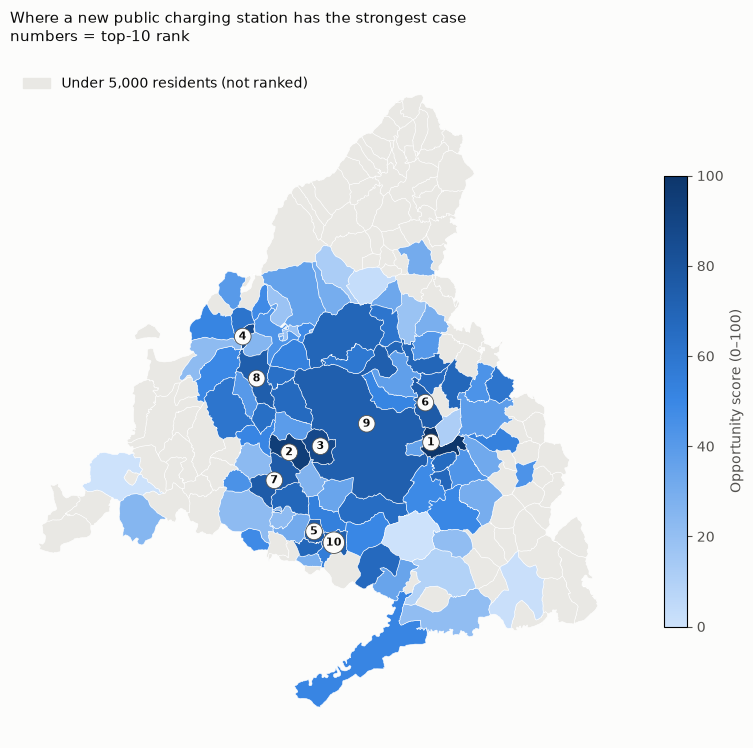

In [6]:
def label_top(ax, df, n=10):
    for _, r in df.nsmallest(n, "rank").iterrows():
        p = r.geometry.representative_point()
        ax.annotate(str(int(r["rank"])), (p.x, p.y), ha="center", va="center", fontsize=8, fontweight="bold",
                    color=INK, bbox=dict(boxstyle="circle,pad=0.25", fc=SURFACE, ec=INK_2, lw=0.6))

fig, ax = plt.subplots(figsize=(8, 8.5))
z[~z["eligible"]].plot(ax=ax, color=NOT_RANKED, edgecolor="white", linewidth=0.4)
z[z["eligible"]].plot(ax=ax, column="score", cmap=BLUES, vmin=0, vmax=100, edgecolor="white", linewidth=0.4,
                      legend=True, legend_kwds={"label": "Opportunity score (0–100)", "shrink": 0.55})
label_top(ax, z)
ax.legend(handles=[Patch(color=NOT_RANKED, label=f"Under {MIN_POP:,} residents (not ranked)")],
          loc="upper left", frameon=False)
ax.set_axis_off()
ax.set_title("Where a new public charging station has the strongest case\nnumbers = top-10 rank",
             loc="left", fontsize=11)
fig.tight_layout()
fig.savefig("maps/04_opportunity_score.png", dpi=200)
plt.show()

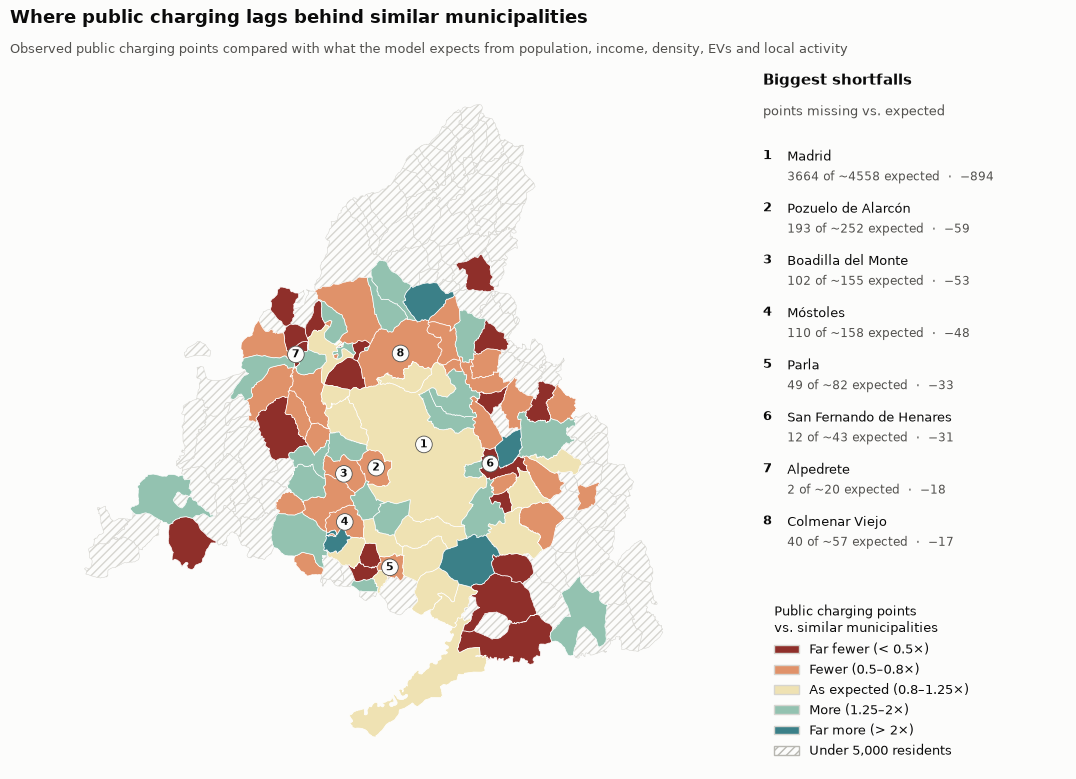

In [11]:
# Five plain-language classes instead of a continuous log scale
BINS   = [0, 0.5, 0.8, 1.25, 2, np.inf]
LABELS = ["Far fewer (< 0.5×)", "Fewer (0.5–0.8×)", "As expected (0.8–1.25×)", "More (1.25–2×)", "Far more (> 2×)"]
COLORS = ["#8f2f2a", "#e0926a", "#efe2b3", "#93c2b0", "#3b8088"]   # brick -> terracotta -> sand -> sage -> slate-teal 
N_LABEL = 8

z["gap_class"] = pd.cut(z["model_ratio"], BINS, labels=LABELS, right=False)
z["gap_points"] = z["expected"] - z["public_points"]
ranked = z[z["eligible"]]
worst = ranked[ranked["model_ratio"] < 1].nlargest(N_LABEL, "gap_points")

fig, (ax, side) = plt.subplots(1, 2, figsize=(11, 8), gridspec_kw={"width_ratios": [3, 1.25]})
z[~z["eligible"]].plot(ax=ax, facecolor=SURFACE, edgecolor="#d6d5d0", linewidth=0.4, hatch="////")
for lab, col in zip(LABELS, COLORS):
    part = ranked[ranked["gap_class"] == lab]
    if len(part):
        part.plot(ax=ax, color=col, edgecolor="white", linewidth=0.5)

for i, (_, r) in enumerate(worst.iterrows(), start=1):
    p = r.geometry.representative_point()
    ax.annotate(str(i), (p.x, p.y), ha="center", va="center", fontsize=8, fontweight="bold", color=INK,
                bbox=dict(boxstyle="circle,pad=0.25", fc=SURFACE, ec=INK_2, lw=0.6))
ax.set_axis_off()

handles = [Patch(facecolor=c, edgecolor="#d6d5d0", label=l) for l, c in zip(LABELS, COLORS)]
handles.append(Patch(facecolor=SURFACE, edgecolor="#b8b7b1", hatch="////", label=f"Under {MIN_POP:,} residents"))
side.legend(handles=handles, title="Public charging points\nvs. similar municipalities", loc="lower left",
            frameon=False, fontsize=9, title_fontsize=9, alignment="left", bbox_to_anchor=(0, 0))

side.set_axis_off()
side.text(0, 1, "Biggest shortfalls", fontsize=11, fontweight="bold", va="top", transform=side.transAxes)
side.text(0, 0.955, "points missing vs. expected", fontsize=9, color=INK_2, va="top", transform=side.transAxes)
for i, (_, r) in enumerate(worst.iterrows(), start=1):
    yy = 0.89 - (i - 1) * 0.075
    side.text(0, yy, f"{i}", fontsize=9, fontweight="bold", va="top", transform=side.transAxes)
    side.text(0.08, yy, r["name"], fontsize=9.5, va="top", transform=side.transAxes)
    side.text(0.08, yy - 0.03, f"{r['public_points']:.0f} of ~{r['expected']:.0f} expected  ·  "
              f"−{r['gap_points']:.0f}", fontsize=8.5, color=INK_2, va="top", transform=side.transAxes)

fig.suptitle("Where public charging lags behind similar municipalities", x=0.02, ha="left",
             fontsize=13, fontweight="bold")
fig.text(0.02, 0.925, "Observed public charging points compared with what the model expects from population, "
         "income, density, EVs and local activity", fontsize=9, color=INK_2)
fig.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.03, wspace=0.05)
fig.savefig("maps/04_gap_map.png", dpi=200)
plt.show()

## 6 · Save

In [8]:
keep = ["ine_code", "name", "population", "eligible", "score", "rank", "rank_best", "rank_worst",
        "top20_in_scenarios", "ev_resident_est", "pop_density_km2", "public_points", "public_fast_sites",
        "evs_per_public_point", "expected", "model_ratio", "p_shortfall", "fuel_stations",
        "dist_nearest_public_km", "fleet_domicile_flag", *[f"pct_{c}" for c in COMPONENTS]]
z[[c for c in keep if c in z.columns]].sort_values("rank").to_csv(PROC / "zone_scores.csv", index=False)

lines = ["# Top-20 candidate municipalities", "",
         f"Weights: {WEIGHTS}. Eligible: ≥ {MIN_POP:,} residents. "
         f"'Robust' = number of the {len(SCENARIOS)} weighting scenarios in which it stays in the top {TOP_N}.", "",
         "| # | Municipality | Score | Resident EVs | Public points | EVs / point | Obs/exp | Robust | Why |",
         "|---|---|---|---|---|---|---|---|---|"]
for _, r in top.iterrows():
    lines.append(f"| {int(r['rank'])} | {r['name']} | {r['score']:.0f} | {r['ev_resident_est']:,.0f} | "
                 f"{int(r['public_points'])} | {r['evs_per_public_point']:,.0f} | {r['model_ratio']:.2f} | "
                 f"{r['robust']} | {r['rationale']} |")
Path("report/top20_candidates.md").write_text("\n".join(lines), encoding="utf-8")
print("Saved data/processed/zone_scores.csv, report/top20_candidates.md, maps/04_opportunity_score.png, maps/04_gap_map.png")

Saved data/processed/zone_scores.csv, report/top20_candidates.md, maps/04_opportunity_score.png, maps/04_gap_map.png


## 7 · Power BI export

Writes flat, analysis-ready tables to `dashboard/data/`, all keyed on `ine_code` (set it to **Text** in Power Query):

| File | Grain | Use in Power BI |
|---|---|---|
| `municipalities.csv` | one row per municipality | features, score, rank, rationale, lat/lon; the main table |
| `chargers.csv` | one row per OCM charging site | Azure Maps points, access-type breakdown |
| `scenario_ranks.csv` | municipality × weighting scenario | rank-stability visual |
| `municipios.topojson` | municipality shapes | Shape map visual (Format → Map settings → Custom map) |

Note to future self: Re-run this section after notebooks 05/06 to add the profit tables. Needs `pip install topojson` for the map file.

In [9]:
PBI = Path("dashboard/data")
PBI.mkdir(parents=True, exist_ok=True)

# 1. Municipalities: every feature + scores + rationale + a label point
label_pt = z.geometry.representative_point().to_crs(4326)
muni = (z.drop(columns="geometry")
          .assign(lat=label_pt.y.values, lon=label_pt.x.values))
muni["rationale"] = muni.apply(rationale, axis=1).where(muni["eligible"], "")
muni["is_top20"] = muni["rank"] <= TOP_N
muni.to_csv(PBI / "municipalities.csv", index=False, encoding="utf-8-sig")

# 2. Charging sites, tagged with their municipality
ocm_path = Path("data/raw/ocm/ocm_chargers.csv")
if ocm_path.exists():
    ocm = pd.read_csv(ocm_path)
    ch = gpd.GeoDataFrame(ocm, geometry=gpd.points_from_xy(ocm["lon"], ocm["lat"]), crs=4326).to_crs(z.crs)
    ch = gpd.sjoin(ch, z[["ine_code", "geometry"]], how="inner", predicate="within")
    ch["is_public"] = ch["access_class"].isin(["public", "public_membership"])
    keep = [c for c in ["ocm_id", "title", "operator", "access_class", "is_public", "max_power_kw",
                        "n_points", "lat", "lon", "ine_code"] if c in ch.columns]
    ch[keep].to_csv(PBI / "chargers.csv", index=False, encoding="utf-8-sig")
else:
    print("data/raw/ocm/ocm_chargers.csv not found; chargers.csv skipped")

# 3. Rank under every weighting scenario (long format: easy to slice in Power BI)
(ranks.assign(ine_code=z["ine_code"].values)[z["eligible"].values]
      .melt(id_vars="ine_code", var_name="scenario", value_name="rank")
      .to_csv(PBI / "scenario_ranks.csv", index=False, encoding="utf-8-sig"))

# 4. Boundaries for the Shape map
try:
    import topojson as tp
    shapes = z[["ine_code", "name", "geometry"]].to_crs(4326)
    topo = tp.Topology(shapes, prequantize=1e5, toposimplify=0.0003).to_json()
    (PBI / "municipios.topojson").write_text(topo, encoding="utf-8")
except ImportError:
    print("topojson not installed; run %pip install topojson to export the map shapes")

for f in sorted(PBI.iterdir()):
    print(f"  {f.name:<24} {f.stat().st_size / 1024:>8,.0f} KB")

  chargers.csv                  265 KB
  municipalities.csv            117 KB
  municipios.topojson           126 KB
  scenario_ranks.csv              8 KB


### Notes for the report
- **A screening tool, not a site decision.** Scores rank municipalities on where to look first. Madrid city is a single
  unit here and needs district-level analysis.
- **Geometric, not additive.** An additive score mostly reproduced population density (ρ = 0.76); the geometric mean
  rewards municipalities that combine demand with undersupply. Report the section 2 correlations alongside the method.
- **Weights are judgement calls**, made explicit and stress-tested in section 3. Report the robust candidates
  (in the top 20 under most scenarios) with more confidence than the rest.
- **Percentile scaling** compares municipalities with each other; a score of 100 means "best in the Comunidad",
  not "guaranteed profitable". The euro case is the job of `05_profit_scenarios`.